In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/global-spice-consumption/Export.csv


In [2]:


arquivo = pd.read_csv('/kaggle/input/global-spice-consumption/Export.csv')

colunas = arquivo.columns

print(colunas)

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Item Code (CPC)', 'Item', 'Year', 'Unit', 'Import', 'Export ',
       'Production', 'Consumption'],
      dtype='object')


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

arquivo_filtrado = arquivo[['Area', 'Year','Item', 'Import','Export ','Production','Consumption']]

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



# arquivo_filtrado = arquivo[['Area', 'Year','Item', 'Import','Export ','Production','Consumption']]
arquivo_filtrado.columns = arquivo_filtrado.columns.str.strip()

X = arquivo_filtrado[["Year", "Area", "Item"]]
X = pd.get_dummies(X, columns=["Area", "Item"])
y = arquivo_filtrado[["Production", "Import", "Export"]]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

modelos = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Rede Neural (MLP)": MLPRegressor(max_iter=1000)
}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    print(f"🔹 {nome}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))
    print("-" * 40)

🔹 Regressão Linear
MAE: 29176.330985269557
MSE: 60836985523.53104
R²: 0.13699553060022454
----------------------------------------
🔹 Árvore de Decisão
MAE: 1022.6440422871837
MSE: 216480869.7015481
R²: 0.9884262462681327
----------------------------------------
🔹 Random Forest
MAE: 863.4928722485747
MSE: 188633299.78647503
R²: 0.9914342349310058
----------------------------------------
🔹 Rede Neural (MLP)
MAE: 22291.027583810588
MSE: 56650582993.331024
R²: 0.18789957344135255
----------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Melhores parâmetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Avaliação no conjunto de teste:
MAE: 863.6892240025726
MSE: 183266260.5217053
R²: 0.9919004838885606

R² médio (validação cruzada): 0.990460091003964


C:\Users\pablo\AppData\Local\Temp\ipykernel_2284\2078316951.py:69: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


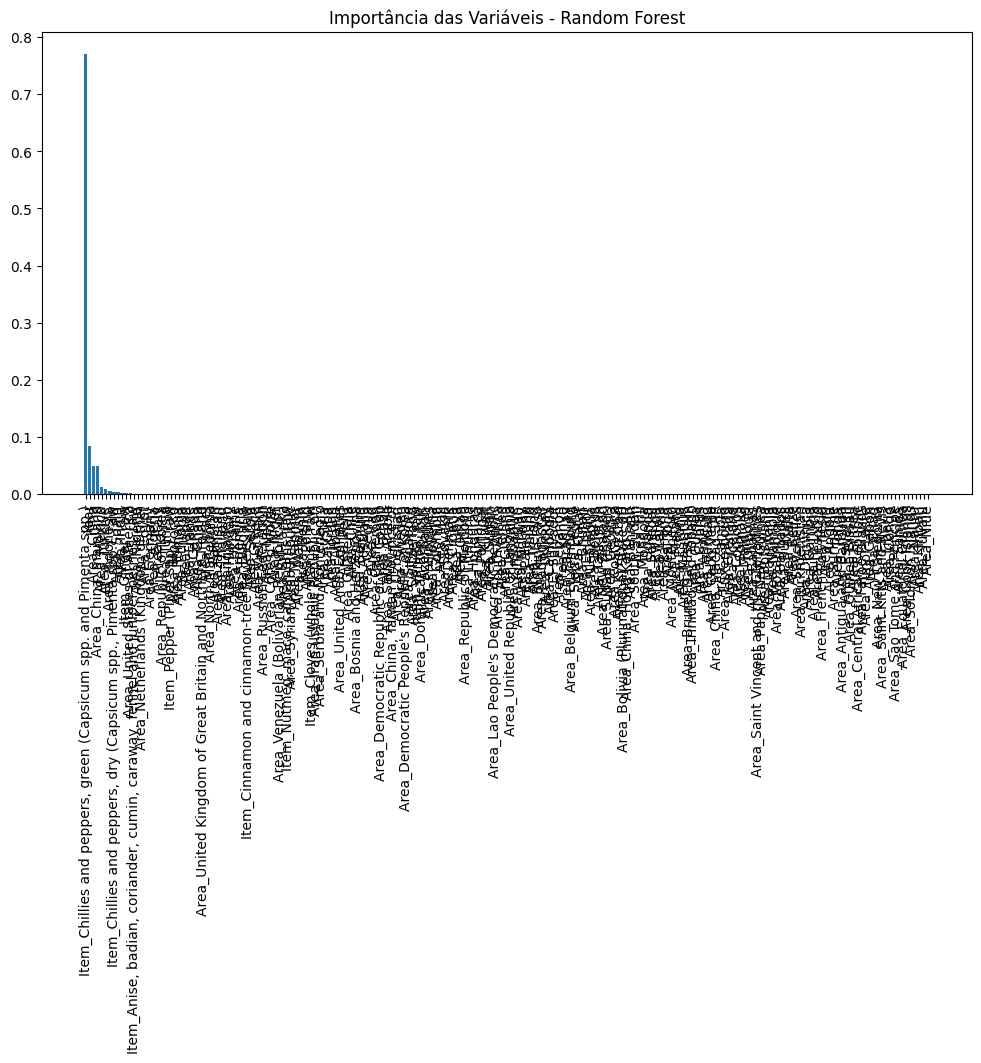

In [10]:

# Mini Trabalho 6 - Otimização e Ajuste Fino do Sistema

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Carregando e preparando os dados
arquivo = pd.read_csv("Export.csv")
arquivo.columns = arquivo.columns.str.strip()

# Corrigindo nomes das colunas
arquivo_filtrado = arquivo[["Area", "Year", "Item", "Import", "Export", "Production", "Consumption"]]

# Separação de variáveis independentes e dependentes
X = arquivo_filtrado[["Year", "Area", "Item"]]
X = pd.get_dummies(X, columns=["Area", "Item"])
y = arquivo_filtrado[["Production", "Import", "Export"]]

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Definição do modelo base e dos hiperparâmetros para ajuste
modelo = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Ajuste com validação cruzada
grid_search = GridSearchCV(estimator=modelo, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Melhores parâmetros:", grid_search.best_params_)

# Avaliação no conjunto de teste
y_pred = grid_search.predict(X_test)
print("\nAvaliação no conjunto de teste:")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Validação cruzada para verificar generalização
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(grid_search.best_estimator_, X, y, cv=kfold, scoring='r2')
print("\nR² médio (validação cruzada):", scores.mean())

# Importância das variáveis
importances = grid_search.best_estimator_.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Importância das Variáveis - Random Forest")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()
